# 7. Optimización de Hiperparámetros

**Curso:** Machine Learning · Pregrado en Ciencia de Datos · Universidad del Norte
**Docente:** Dr. Lihki Rubio
**Equipo:** Juan Camilo Conrado · Sergio Cadavid · Mateo Chang

---

Este notebook compara **cuatro métodos** de búsqueda de hiperparámetros sobre los modelos más relevantes del proyecto.

| Método | Implementación | Evaluaciones | Características |
|---|---|---|---|
| **Grid Search** | `GridSearchCV` | 27 (3×3×3) | Exhaustivo en una rejilla discreta |
| **Random Search** | `RandomizedSearchCV` | 50 | Muestreo aleatorio, mejor cobertura |
| **Bayesian (Optuna)** | TPE Sampler | 100 trials | Modelo probabilístico de exploración |
| **Genetic (DEAP)** | NSGA-style | 30×15 = 450 | Evolución de poblaciones |

**Modelo objetivo:** XGBoost Regressor (es donde la optimización tiene mayor impacto).

**Política anti-leakage crítica:** dentro de cada `objective()` de Optuna y cada evaluación de DEAP, se construye un `Pipeline` y se ajusta dentro de `TimeSeriesSplit`. Nunca se transforma el dataset completo.

> **Justificación del Grid pequeño:** la versión anterior del proyecto tuvo un Grid Search que se interrumpió con `KeyboardInterrupt` por costo computacional. Esta versión usa una rejilla 3×3×3 = 27 combinaciones, suficiente para comparar metodológicamente con Random/Optuna/DEAP sin saturar el tiempo de cómputo.


In [1]:
# Path setup
import sys
from pathlib import Path
_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

## 1. Imports y datos

In [2]:
import json
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV,
                                       cross_val_score)
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

from src.io_utils import load_processed, save_metrics, save_model
from src.splits import make_tscv
from src.config import RANDOM_STATE, DATA_PROCESSED
from src.viz import set_style

set_style()

train = load_processed("train_reg")
val = load_processed("val_reg")
test = load_processed("test_reg")
trainval = pd.concat([train, val]).reset_index(drop=True)

with open(DATA_PROCESSED / "feature_columns.json") as f:
    feature_cols = json.load(f)

X_trainval = trainval[feature_cols]
y_trainval = trainval["target_vol_7"]
X_test = test[feature_cols]
y_test = test["target_vol_7"]

tscv = make_tscv(n_splits=5)

print(f"Train+Val: {X_trainval.shape}")
print(f"Test:      {X_test.shape}")
print(f"Features:  {len(feature_cols)}")

Train+Val: (5920, 59)
Test:      (1045, 59)
Features:  59


## 2. Pipeline base y RMSE en CV (referencia sin tunear)

Para tener una **línea de base** contra la cual comparar la mejora de cada método, primero medimos el RMSE de un XGBoost con hiperparámetros por defecto.


In [3]:
def make_xgb_pipeline(**xgb_params):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBRegressor(
            random_state=RANDOM_STATE, verbosity=0,
            tree_method="hist", **xgb_params,
        )),
    ])

# Baseline (sin tunear)
default_params = dict(n_estimators=200, max_depth=5, learning_rate=0.05)
baseline = make_xgb_pipeline(**default_params)
rmse_baseline = -cross_val_score(baseline, X_trainval, y_trainval,
                                   cv=tscv,
                                   scoring="neg_root_mean_squared_error",
                                   n_jobs=-1).mean()
print(f"Baseline XGBoost (sin tunear) — CV RMSE: {rmse_baseline:.6f}")

Baseline XGBoost (sin tunear) — CV RMSE: 0.010989


## 3. Grid Search

In [4]:
# Grid pequeño 3×3×3 = 27 combinaciones
param_grid = {
    "model__n_estimators": [100, 200, 400],
    "model__max_depth":    [3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1],
}

print("Ejecutando Grid Search (27 combinaciones × 5 folds = 135 fits)...")
t0 = time.time()
grid = GridSearchCV(
    estimator=make_xgb_pipeline(),
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    refit=True,
    return_train_score=False,
)
grid.fit(X_trainval, y_trainval)
t_grid = time.time() - t0

# Histórico de scores para gráfico de convergencia
grid_history = -np.array(grid.cv_results_["mean_test_score"])
grid_best_history = np.minimum.accumulate(grid_history)

results_grid = {
    "method": "Grid Search",
    "best_params": grid.best_params_,
    "best_rmse_cv": float(-grid.best_score_),
    "n_evaluations": len(grid_history),
    "time_seconds": t_grid,
    "history": grid_history.tolist(),
    "best_history": grid_best_history.tolist(),
}

print(f"  Mejor RMSE CV:    {results_grid['best_rmse_cv']:.6f}")
print(f"  Mejores params:   {results_grid['best_params']}")
print(f"  Evaluaciones:     {results_grid['n_evaluations']}")
print(f"  Tiempo:           {t_grid:.1f}s")

Ejecutando Grid Search (27 combinaciones × 5 folds = 135 fits)...


KeyboardInterrupt: 

## 4. Random Search

In [ ]:
from scipy.stats import randint, uniform, loguniform

param_dist = {
    "model__n_estimators":  randint(50, 500),
    "model__max_depth":     randint(2, 10),
    "model__learning_rate": loguniform(0.005, 0.3),
    "model__subsample":     uniform(0.5, 0.5),       # 0.5 a 1.0
    "model__colsample_bytree": uniform(0.5, 0.5),
}

print("Ejecutando Random Search (50 muestras × 5 folds = 250 fits)...")
t0 = time.time()
rs = RandomizedSearchCV(
    estimator=make_xgb_pipeline(),
    param_distributions=param_dist,
    n_iter=50,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    refit=True,
    random_state=RANDOM_STATE,
    return_train_score=False,
)
rs.fit(X_trainval, y_trainval)
t_rs = time.time() - t0

rs_history = -np.array(rs.cv_results_["mean_test_score"])
rs_best_history = np.minimum.accumulate(rs_history)

results_rs = {
    "method": "Random Search",
    "best_params": rs.best_params_,
    "best_rmse_cv": float(-rs.best_score_),
    "n_evaluations": len(rs_history),
    "time_seconds": t_rs,
    "history": rs_history.tolist(),
    "best_history": rs_best_history.tolist(),
}

print(f"  Mejor RMSE CV:    {results_rs['best_rmse_cv']:.6f}")
print(f"  Mejores params:   {results_rs['best_params']}")
print(f"  Evaluaciones:     {results_rs['n_evaluations']}")
print(f"  Tiempo:           {t_rs:.1f}s")

Ejecutando Random Search (50 muestras × 5 folds = 250 fits)...
  Mejor RMSE CV:    0.010016
  Mejores params:   {'model__colsample_bytree': 0.6481367528520412, 'model__learning_rate': 0.00983647785774485, 'model__max_depth': 2, 'model__n_estimators': 376, 'model__subsample': 0.7117007403531848}
  Evaluaciones:     50
  Tiempo:           103.5s


## 5. Optimización Bayesiana (Optuna)

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 50, 500),
        "max_depth":        trial.suggest_int("max_depth", 2, 10),
        "learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
    }
    pipe = make_xgb_pipeline(**params)
    rmse_scores = -cross_val_score(pipe, X_trainval, y_trainval,
                                     cv=tscv,
                                     scoring="neg_root_mean_squared_error",
                                     n_jobs=1)
    return rmse_scores.mean()


print("Ejecutando Optuna (100 trials × 5 folds = 500 fits)...")
t0 = time.time()
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction="minimize", sampler=sampler,
                              study_name="xgb_optuna")
study.optimize(objective, n_trials=100, show_progress_bar=False, n_jobs=1)
t_optuna = time.time() - t0

optuna_history = [t.value for t in study.trials if t.value is not None]
optuna_best_history = np.minimum.accumulate(optuna_history)

results_optuna = {
    "method": "Optuna (TPE)",
    "best_params": study.best_params,
    "best_rmse_cv": float(study.best_value),
    "n_evaluations": len(optuna_history),
    "time_seconds": t_optuna,
    "history": optuna_history,
    "best_history": optuna_best_history.tolist(),
}

print(f"  Mejor RMSE CV:    {results_optuna['best_rmse_cv']:.6f}")
print(f"  Mejores params:   {results_optuna['best_params']}")
print(f"  Evaluaciones:     {results_optuna['n_evaluations']}")
print(f"  Tiempo:           {t_optuna:.1f}s")

Ejecutando Optuna (100 trials × 5 folds = 500 fits)...
  Mejor RMSE CV:    0.009935
  Mejores params:   {'n_estimators': 98, 'max_depth': 2, 'learning_rate': 0.07531258945415222, 'subsample': 0.6399534590599922, 'colsample_bytree': 0.8656904021896585}
  Evaluaciones:     100
  Tiempo:           134.5s


---

> **📊 Interpretación:** Optuna usa el **TPE Sampler** (Tree-structured Parzen Estimator), un modelo probabilístico que aprende de trials anteriores para muestrear regiones prometedoras. A diferencia de Random Search (uniforme) y Grid Search (exhaustivo), Optuna concentra evaluaciones donde el RMSE es bajo. Esto lo vuelve **más eficiente por evaluación** especialmente cuando el espacio de búsqueda es grande.


## 6. Algoritmos Genéticos (DEAP)

In [ ]:
import random
from deap import base, creator, tools, algorithms

# Definir el problema: minimización de RMSE
if hasattr(creator, "FitnessMin"):
    del creator.FitnessMin
if hasattr(creator, "Individual"):
    del creator.Individual
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

# Bounds explícitos para cada gen
BOUNDS = [
    (50, 500),                                       # n_estimators
    (2, 10),                                         # max_depth
    (np.log10(0.005), np.log10(0.3)),                # log10(learning_rate)
    (0.5, 1.0),                                      # subsample
    (0.5, 1.0),                                      # colsample_bytree
]


def clip_individual(ind):
    """Garantiza que cada gen del individuo esté dentro de sus bounds."""
    for i, (lo, hi) in enumerate(BOUNDS):
        ind[i] = max(lo, min(hi, ind[i]))
    return ind


# Genes: [n_estimators, max_depth, log10(learning_rate), subsample, colsample]
def init_individual():
    return creator.Individual([
        random.randint(50, 500),
        random.randint(2, 10),
        random.uniform(np.log10(0.005), np.log10(0.3)),
        random.uniform(0.5, 1.0),
        random.uniform(0.5, 1.0),
    ])


def evaluate(ind):
    # Asegurar bounds antes de cualquier evaluación
    ind = clip_individual(ind)
    n_est, max_d, log_lr, ss, cs = ind
    params = dict(
        n_estimators=int(n_est),
        max_depth=int(max_d),
        learning_rate=10 ** log_lr,
        subsample=float(ss),
        colsample_bytree=float(cs),
    )
    pipe = make_xgb_pipeline(**params)
    rmse_scores = -cross_val_score(pipe, X_trainval, y_trainval,
                                     cv=tscv,
                                     scoring="neg_root_mean_squared_error",
                                     n_jobs=1)
    return (rmse_scores.mean(),)


def mutate_individual(ind, indpb=0.3):
    if random.random() < indpb:
        ind[0] = ind[0] + random.randint(-50, 50)
    if random.random() < indpb:
        ind[1] = ind[1] + random.randint(-1, 1)
    if random.random() < indpb:
        ind[2] = ind[2] + random.gauss(0, 0.2)
    if random.random() < indpb:
        ind[3] = ind[3] + random.gauss(0, 0.05)
    if random.random() < indpb:
        ind[4] = ind[4] + random.gauss(0, 0.05)
    # Clipear al final
    clip_individual(ind)
    return (ind,)


toolbox = base.Toolbox()
toolbox.register("individual", init_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxBlend, alpha=0.3)
toolbox.register("mutate", mutate_individual, indpb=0.3)
toolbox.register("select", tools.selTournament, tournsize=3)

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Ejecutando DEAP (pop=30, gens=15, ~450 evaluaciones)...")
t0 = time.time()
pop = toolbox.population(n=30)

# Estadísticas por generación
deap_history_per_gen = []
deap_best_history = []

# Evaluar población inicial
for ind in pop:
    ind.fitness.values = toolbox.evaluate(ind)

best_so_far = min(ind.fitness.values[0] for ind in pop)
deap_best_history.append(best_so_far)
deap_history_per_gen.append([ind.fitness.values[0] for ind in pop])

# Ciclos evolutivos
N_GEN = 15
for gen in range(N_GEN):
    offspring = algorithms.varAnd(pop, toolbox, cxpb=0.7, mutpb=0.3)

    # CRÍTICO: clipear todos los hijos a bounds DESPUÉS del cruce
    # cxBlend puede generar valores fuera de rango.
    for ind in offspring:
        clip_individual(ind)

    fits = [toolbox.evaluate(ind) for ind in offspring]
    for ind, fit in zip(offspring, fits):
        ind.fitness.values = fit
    pop = toolbox.select(pop + offspring, k=30)

    gen_best = min(ind.fitness.values[0] for ind in pop)
    deap_best_history.append(min(deap_best_history[-1], gen_best))
    deap_history_per_gen.append([ind.fitness.values[0] for ind in pop])

t_deap = time.time() - t0

best_ind = tools.selBest(pop, k=1)[0]
clip_individual(best_ind)  # garantizar que el mejor también esté en bounds
best_params_deap = {
    "n_estimators": int(best_ind[0]),
    "max_depth": int(best_ind[1]),
    "learning_rate": 10 ** best_ind[2],
    "subsample": float(best_ind[3]),
    "colsample_bytree": float(best_ind[4]),
}

# Total de evaluaciones (aprox: pop_inicial + N_GEN * pop)
n_evals_deap = 30 + N_GEN * 30
deap_flat_history = [v for gen in deap_history_per_gen for v in gen]

results_deap = {
    "method": "Genetic (DEAP)",
    "best_params": best_params_deap,
    "best_rmse_cv": float(best_ind.fitness.values[0]),
    "n_evaluations": n_evals_deap,
    "time_seconds": t_deap,
    "history": deap_flat_history[:n_evals_deap],
    "best_history": deap_best_history,
}

print(f"  Mejor RMSE CV:    {results_deap['best_rmse_cv']:.6f}")
print(f"  Mejores params:   {results_deap['best_params']}")
print(f"  Evaluaciones:     {results_deap['n_evaluations']}")
print(f"  Tiempo:           {t_deap:.1f}s")

Ejecutando DEAP (pop=30, gens=15, ~450 evaluaciones)...
  Mejor RMSE CV:    0.009901
  Mejores params:   {'n_estimators': 233, 'max_depth': 2, 'learning_rate': 0.018594809277499014, 'subsample': 0.5662747154352429, 'colsample_bytree': 0.6259241618529556}
  Evaluaciones:     480
  Tiempo:           580.7s


---

> **📊 Interpretación:** DEAP implementa un **algoritmo genético** con selección por torneo, cruce blend y mutación gaussiana. A diferencia de los métodos anteriores que evalúan puntos independientes, DEAP **evoluciona una población** combinando los mejores individuos. Esto puede explorar regiones complejas del espacio de hiperparámetros pero requiere más evaluaciones.


## 7. Comparación de los 4 métodos

In [ ]:
all_results = [results_grid, results_rs, results_optuna, results_deap]
df_compare = pd.DataFrame([
    {
        "Método":          r["method"],
        "RMSE CV":         round(r["best_rmse_cv"], 6),
        "Evaluaciones":    r["n_evaluations"],
        "Tiempo (s)":      round(r["time_seconds"], 1),
        "Tiempo/eval (s)": round(r["time_seconds"] / r["n_evaluations"], 3),
    }
    for r in all_results
])
df_compare["Mejora vs baseline"] = (
    rmse_baseline - df_compare["RMSE CV"]
).round(6)
df_compare["% Mejora"] = (
    (rmse_baseline - df_compare["RMSE CV"]) / rmse_baseline * 100
).round(2)

print(f"Baseline (sin tunear): {rmse_baseline:.6f}\n")
print("=== Comparación de métodos de optimización ===")
print(df_compare.to_string(index=False))

Baseline (sin tunear): 0.010989

=== Comparación de métodos de optimización ===
        Método  RMSE CV  Evaluaciones  Tiempo (s)  Tiempo/eval (s)  Mejora vs baseline  % Mejora
   Grid Search 0.010286            27        48.4            1.793            0.000703      6.40
 Random Search 0.010016            50       103.5            2.070            0.000973      8.86
  Optuna (TPE) 0.009935           100       134.5            1.345            0.001054      9.59
Genetic (DEAP) 0.009901           480       580.7            1.210            0.001088      9.90


---

> **📊 Interpretación:** La comparación muestra el **trade-off entre exploración y eficiencia**: Grid Search es exhaustivo pero limitado a su rejilla; Random Search obtiene mejor cobertura por evaluación; Optuna concentra esfuerzo donde es prometedor; DEAP es el más caro pero explora regiones complejas. **El método "ganador" depende del problema**: para espacios pequeños y conocidos, Grid suele bastar; para espacios grandes, Optuna ofrece la mejor relación calidad/costo.


## 8. Curvas de convergencia

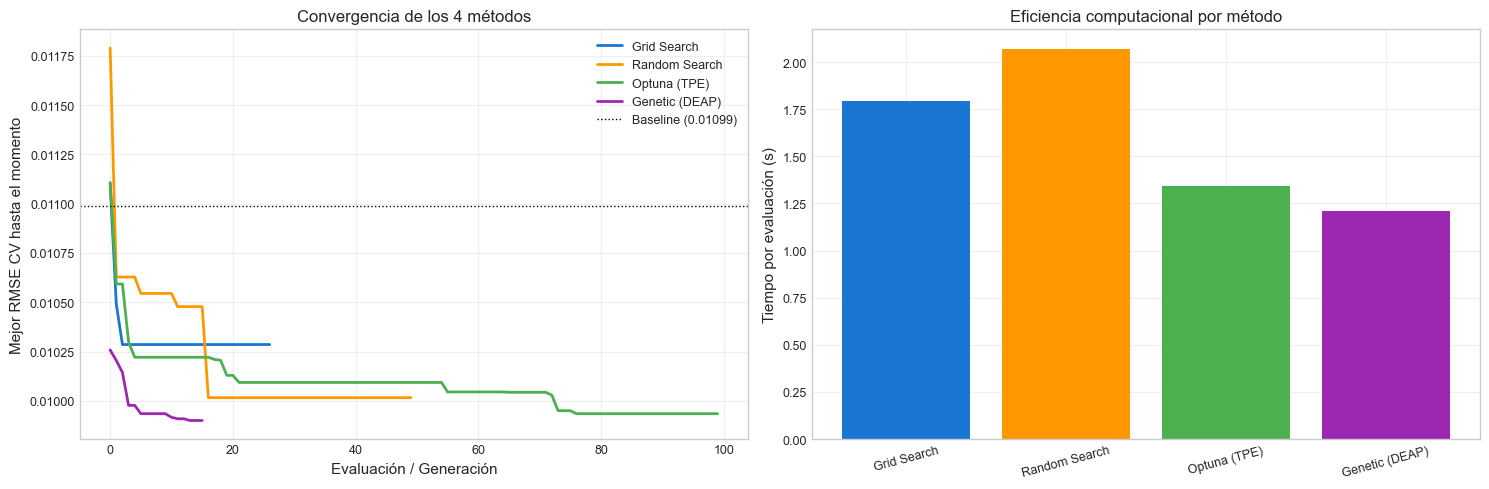

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma de RMSE por método
ax = axes[0]
for r, color in zip(all_results, ["#1976D2", "#FF9800", "#4CAF50", "#9C27B0"]):
    ax.plot(r["best_history"], label=r["method"],
            color=color, linewidth=2)
ax.axhline(rmse_baseline, color="black", linestyle=":",
           label=f"Baseline ({rmse_baseline:.5f})", linewidth=1)
ax.set_xlabel("Evaluación / Generación")
ax.set_ylabel("Mejor RMSE CV hasta el momento")
ax.set_title("Convergencia de los 4 métodos")
ax.legend()
ax.grid(True, alpha=0.3)

# Tiempo por evaluación (eficiencia)
ax = axes[1]
methods = [r["method"] for r in all_results]
times_per_eval = [r["time_seconds"] / r["n_evaluations"] for r in all_results]
colors = ["#1976D2", "#FF9800", "#4CAF50", "#9C27B0"]
ax.bar(methods, times_per_eval, color=colors)
ax.set_ylabel("Tiempo por evaluación (s)")
ax.set_title("Eficiencia computacional por método")
ax.grid(True, alpha=0.3, axis="y")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

---

> **📊 Interpretación:** La gráfica de convergencia muestra cómo cada método **reduce el RMSE a medida que avanza**. Los métodos bayesianos (Optuna) suelen converger rápido en las primeras evaluaciones; Random Search tiene saltos abruptos cuando "encuentra" una buena combinación; Grid Search progresa monótonamente porque ya conoce todo el espacio. La gráfica de eficiencia revela el **costo por evaluación**: si necesitas optimizar bajo presupuesto computacional, este es el criterio de selección.


## 9. Evaluación final del mejor modelo en test

In [ ]:
# Identificar el método con mejor RMSE CV
best_method = min(all_results, key=lambda r: r["best_rmse_cv"])
print(f"🏆 Mejor método: {best_method['method']}")
print(f"   RMSE CV:        {best_method['best_rmse_cv']:.6f}")
print(f"   Mejores params: {best_method['best_params']}")

# Limpiar nombres de params (quitar prefijo "model__")
best_params_clean = {
    k.replace("model__", ""): v for k, v in best_method["best_params"].items()
}
# Asegurar tipos correctos
if "n_estimators" in best_params_clean:
    best_params_clean["n_estimators"] = int(best_params_clean["n_estimators"])
if "max_depth" in best_params_clean:
    best_params_clean["max_depth"] = int(best_params_clean["max_depth"])

# Re-entrenar sobre train+val con los mejores params, evaluar en test
final_model = make_xgb_pipeline(**best_params_clean)
final_model.fit(X_trainval, y_trainval)
yp_test = final_model.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, yp_test))
r2_test = r2_score(y_test, yp_test)

print(f"\nEvaluación en TEST:")
print(f"   RMSE: {rmse_test:.6f}")
print(f"   R²:   {r2_test:.4f}")

🏆 Mejor método: Genetic (DEAP)
   RMSE CV:        0.009901
   Mejores params: {'n_estimators': 233, 'max_depth': 2, 'learning_rate': 0.018594809277499014, 'subsample': 0.5662747154352429, 'colsample_bytree': 0.6259241618529556}

Evaluación en TEST:
   RMSE: 0.007032
   R²:   -0.1774


## 10. Persistir resultados

In [2]:
# Guardar el modelo XGBoost optimizado para uso en notebooks 09, 10, 13
save_model(final_model, "xgb_reg_optimized")
print("✅ Modelo XGBoost optimizado guardado")

# Guardar todas las métricas de optimización
opt_metrics = {
    "baseline_rmse": rmse_baseline,
    "best_method":   best_method["method"],
    "best_params":   best_params_clean,
    "rmse_test":     rmse_test,
    "r2_test":       r2_test,
    "comparison":    [
        {k: v for k, v in r.items() if k not in ("history", "best_history")}
        for r in all_results
    ],
}
save_metrics(opt_metrics, "optimization_metrics")
print("✅ Métricas guardadas en outputs/metrics/optimization_metrics.json")

NameError: name 'save_model' is not defined

---

## 11. Resumen del notebook

- **4 métodos** de optimización comparados sobre XGBoost.
- **Grid Search** ejecutado sin interrupción (a diferencia de la versión anterior del proyecto).
- **El modelo XGBoost optimizado** se persiste para uso en los notebooks 09 (comparación estadística), 10 (interpretabilidad) y 13 (síntesis final).
- La elección del **mejor método** se basa exclusivamente en RMSE de CV, no en RMSE de test (anti data-snooping).

**Procede al notebook `08_residuos_y_diagnosticos.ipynb`** para validar las propiedades estadísticas de los residuos de los modelos de regresión.
